## Cell 1 -- Imports & Configuration

In [1]:
import asyncio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from collections import deque
from concurrent.futures import ThreadPoolExecutor
from scipy import signal
from scipy.signal import welch
from scipy.integrate import trapezoid
from IPython.display import display

# idun_guardian_sdk is only needed in live mode.
try:
    from idun_guardian_sdk import GuardianClient
    _SDK_AVAILABLE = True
except ImportError:
    _SDK_AVAILABLE = False

MODE = "offline"   # "offline" | "live"

fs             = 250
WINDOW_SECONDS = 6
BUFFER_SIZE    = fs * WINDOW_SECONDS

# If True, alpha/theta/beta band boundaries are anchored to the individual's
# peak alpha frequency (IAF) measured during calibration rather than fixed values.
# Acceptance range: IAF_MIN-IAF_MAX Hz (typical for young adult males: 9-12 Hz).
# Set to False to always use standard bands (8-12 Hz).
USE_IAF = False
IAF_MIN = 9.0    # Hz -- lower bound for valid IAF
IAF_MAX = 12.0   # Hz -- upper bound for valid IAF

CALIBRATION_SECONDS = 60

BANDS = {
    "delta": (0.5, 4),
    "theta": (4,   8),
    "alpha": (8,  12),
    "beta":  (12, 30),
    "gamma": (30, 40),
}

# Offline
CSV_FILE       = "livedata_test.csv"
PLAYBACK_SPEED = 10.0
CHUNK_SIZE     = 50
EVENT_TIMES    = [120, 480, 600, 780, 900]

# Live
MY_API_TOKEN       = "idun_MWSQ4pkewAGNz8wwYzw_NsweXihLC8tIcFzah8vqqys4Nc-ALzjfTwl2"
DEVICE_ADDRESS     = "E0:53:73:AB:F9:05"
RECORDING_DURATION = 600

SMOOTHING_ALPHA    = 0.08
STATE_MIN_SECONDS  = 2.0
RELAX_BOOST        = 0.0
FOCUSED_BOOST      = 0.0
AUDIO_COOLDOWN     = 12.0
PLOT_WINDOW_SECONDS = 0
UPDATE_INTERVAL    = 0.1

_executor = ThreadPoolExecutor(max_workers=2)

## Cell 2 -- Filters & Signal Processing

In [2]:
sos_bp = signal.butter(N=4, Wn=[1, 40], btype="bandpass", fs=fs, output="sos")
b_notch, a_notch = signal.iirnotch(50, Q=30, fs=fs)

_zi_bp    = signal.sosfilt_zi(sos_bp) * 0
_zi_notch = signal.lfilter_zi(b_notch, a_notch) * 0

nperseg  = fs * (WINDOW_SECONDS // 2)
noverlap = nperseg // 2


def apply_filters(data: np.ndarray) -> np.ndarray:
    global _zi_bp, _zi_notch
    data = np.asarray(data, dtype=float)
    if len(data) < 50:
        return data
    filtered, _zi_notch = signal.lfilter(b_notch, a_notch, data, zi=_zi_notch)
    filtered, _zi_bp    = signal.sosfilt(sos_bp, filtered, zi=_zi_bp)
    return filtered - np.mean(filtered)


def reset_filter_state():
    global _zi_bp, _zi_notch
    _zi_bp    = signal.sosfilt_zi(sos_bp) * 0
    _zi_notch = signal.lfilter_zi(b_notch, a_notch) * 0


def _welch_only(filtered: np.ndarray):
    if len(filtered) < nperseg:
        return None, None
    freqs, psd = welch(
        filtered, fs=fs, nperseg=nperseg, noverlap=noverlap,
        window="hann", scaling="density"
    )
    return freqs, psd


def band_power(freqs: np.ndarray, psd: np.ndarray, band: tuple) -> float:
    idx = (freqs >= band[0]) & (freqs <= band[1])
    return float(trapezoid(psd[idx], freqs[idx])) if np.any(idx) else 0.0


def compute_features(freqs: np.ndarray, psd: np.ndarray,
                     theta_baseline: float) -> dict:
    # engagement = beta / max(alpha + (theta - theta_baseline), floor)
    #   theta below baseline -> engagement high -> FOCUSED
    #   theta above baseline -> engagement lower -> DRIFTING likely
    eps   = 1e-8
    theta = band_power(freqs, psd, BANDS["theta"])
    alpha = band_power(freqs, psd, BANDS["alpha"])
    beta  = band_power(freqs, psd, BANDS["beta"])
    theta_dev = theta - theta_baseline
    eng_denom = max(alpha + theta_dev, theta_baseline * 0.1 + eps)
    return {
        "engagement": beta  / eng_denom,
        "relaxation": alpha / (beta  + eps),
        "_theta": theta,
        "_alpha": alpha,
        "_beta":  beta,
    }

## Cell 3 -- Buffer, Calibration & Classifier

In [ ]:
class LiveData:
    def __init__(self):
        self.timestamps = deque(maxlen=BUFFER_SIZE)
        self.ch1        = deque(maxlen=BUFFER_SIZE)
        self.is_running = True

live_buffer = LiveData()


class Calibration:
    def __init__(self):
        self._raw           = []
        self._psds          = []
        self._freqs         = None
        self.theta_baseline = 1e-8
        self.iaf            = None
        self.avg_psd        = None
        self.paf            = None
        self.cog            = None
        self.end_time       = None
        self.complete       = False

    def add_sample(self, features: dict):
        self._raw.append({k: features[k] for k in ("_theta", "_alpha", "_beta")})

    def add_psd(self, freqs: np.ndarray, psd: np.ndarray):
        if self._freqs is None:
            self._freqs = freqs
        self._psds.append(psd)

    def finalize(self):
        thetas = np.array([s["_theta"] for s in self._raw])
        self.theta_baseline = float(np.mean(thetas)) or 1e-8

        if USE_IAF and self._psds and self._freqs is not None:
            avg_psd = np.mean(self._psds, axis=0)
            mask = (self._freqs >= 7) & (self._freqs <= 13)
            fa, pa = self._freqs[mask], avg_psd[mask]
            if len(fa) > 0 and pa.sum() > 0:
                iaf = float(fa[np.argmax(pa)])
                # Accept only within IAF_MIN-IAF_MAX (typical young adult male: 9-12 Hz)
                if IAF_MIN <= iaf <= IAF_MAX:
                    self.iaf = iaf
                    BANDS["theta"] = (4.0,             round(iaf - 2, 2))
                    BANDS["alpha"] = (round(iaf - 2, 2), round(iaf + 2, 2))
                    BANDS["beta"]  = (round(iaf + 2, 2), 30.0)
                else:
                    print(f"IAF candidate {iaf:.2f} Hz outside valid range "
                          f"({IAF_MIN}-{IAF_MAX} Hz) -- using standard bands")

        if self._psds and self._freqs is not None:
            self.avg_psd = np.mean(self._psds, axis=0)
            mask_wide = (self._freqs >= 7) & (self._freqs <= 13)
            fw, pw = self._freqs[mask_wide], self.avg_psd[mask_wide]
            if len(fw) > 0 and pw.sum() > 0:
                self.paf = float(fw[np.argmax(pw)])
                self.cog = float(np.sum(fw * pw) / np.sum(pw))

        self.complete = True


calibration = Calibration()


def reset_state():
    """Reset all session state so main() can be re-run without a kernel restart."""
    global calibration, _smoothed, _dwell_candidate, _dwell_count
    global _confirmed_state, _dwell_frames_cached
    global _last_audio_time, _last_announced_state

    calibration = Calibration()

    BANDS["theta"] = (4.0,  8.0)
    BANDS["alpha"] = (8.0, 12.0)
    BANDS["beta"]  = (12.0, 30.0)

    for k in _smoothed:
        _smoothed[k] = None

    _dwell_candidate     = None
    _dwell_count         = 0
    _confirmed_state     = "CALIBRATING"
    _dwell_frames_cached = max(1, int(STATE_MIN_SECONDS / UPDATE_INTERVAL))

    _last_audio_time      = 0.0
    _last_announced_state = None


_smoothed = {"engagement": None, "relaxation": None}

def smooth_features(raw: dict) -> dict:
    for key in _smoothed:
        if _smoothed[key] is None:
            _smoothed[key] = raw[key]
        else:
            _smoothed[key] = (SMOOTHING_ALPHA * raw[key]
                              + (1 - SMOOTHING_ALPHA) * _smoothed[key])
    return dict(_smoothed)


STATE_COLORS = {
    "CALIBRATING": "gray",
    "FOCUSED":     "mediumseagreen",
    "DRIFTING":    "steelblue",
}

_KEY_TO_STATE = {
    "engagement": "FOCUSED",
    "relaxation": "DRIFTING",
}

_dwell_candidate     = None
_dwell_count         = 0
_confirmed_state     = "CALIBRATING"
_dwell_frames_cached = max(1, int(2.0 / 0.1))

def _update_dwell_cache():
    global _dwell_frames_cached
    _dwell_frames_cached = max(1, int(STATE_MIN_SECONDS / UPDATE_INTERVAL))

def classify(smooth: dict) -> str:
    scores = {
        "engagement": smooth["engagement"] + FOCUSED_BOOST,
        "relaxation": smooth["relaxation"] + RELAX_BOOST,
    }
    global _dwell_candidate, _dwell_count, _confirmed_state
    candidate = _KEY_TO_STATE[max(
        ("engagement", "relaxation"),
        key=lambda k: scores[k]
    )]
    if candidate == _dwell_candidate:
        _dwell_count += 1
    else:
        _dwell_candidate = candidate
        _dwell_count     = 1
    if _dwell_count >= _dwell_frames_cached:
        _confirmed_state = candidate
    return _confirmed_state

## Cell 4 -- Audio Feedback

In [4]:
# sounddevice imported lazily inside maybe_announce to avoid blocking BLE scan
_AUDIO_FS = 44100

def _make_focus_chime():
    def note(freq, dur, delay=0.0):
        total  = int(_AUDIO_FS * (dur + delay))
        t      = np.linspace(0, dur + delay, total)
        attack = np.clip(t / 0.06, 0, 1)
        decay  = np.exp(-3.5 * np.maximum(t - 0.06, 0))
        seg    = np.sin(2 * np.pi * freq * t) * attack * decay * 0.45
        seg[:int(_AUDIO_FS * delay)] = 0
        return seg
    n1 = note(523, 0.7, delay=0.0)
    n2 = note(659, 0.7, delay=0.18)
    length = max(len(n1), len(n2))
    mix = np.zeros(length)
    mix[:len(n1)] += n1
    mix[:len(n2)] += n2
    return mix.astype(np.float32)

def _make_drift_tone():
    dur   = 1.0
    t     = np.linspace(0, dur, int(_AUDIO_FS * dur))
    freq  = 330 - 110 * (t / dur)
    phase = np.cumsum(2 * np.pi * freq / _AUDIO_FS)
    env   = np.exp(-4 * (t - 0.35) ** 2)
    return (np.sin(phase) * env * 0.45).astype(np.float32)

_SND_FOCUS = _make_focus_chime()
_SND_DRIFT = _make_drift_tone()

_last_audio_time      = 0.0
_last_announced_state = None

_STATE_SOUND = {
    "FOCUSED":  _SND_FOCUS,
    "DRIFTING": _SND_DRIFT,
}

def maybe_announce(state: str, current_time: float):
    import sounddevice as sd  # lazy import -- keeps BLE scan unblocked at startup
    global _last_audio_time, _last_announced_state
    if state == "CALIBRATING":
        return
    if (state != _last_announced_state
            and (current_time - _last_audio_time) >= AUDIO_COOLDOWN):
        snd = _STATE_SOUND.get(state)
        if snd is not None:
            sd.play(snd, _AUDIO_FS)
        _last_announced_state = state
        _last_audio_time      = current_time

## Cell 5 -- Data Handler

In [5]:
_start_time = None
_dirty      = False

def handle_live_data(event):
    global _dirty
    if isinstance(event, dict):
        msg = event.get("message", {})
    else:
        msg = getattr(event, "message", {}) or {}
    raw = msg.get("raw_eeg", []) if isinstance(msg, dict) else []
    for sample in raw:
        live_buffer.ch1.append(sample.get("ch1", 0.0))
        live_buffer.timestamps.append(sample.get("timestamp", 0.0))
    _dirty = True

## Cell 6 -- Processing & Plot Loop

In [6]:
def _show_calibration_plot():
    if calibration.avg_psd is None or calibration._freqs is None:
        return
    freqs   = calibration._freqs
    avg_psd = calibration.avg_psd
    display_bands = [
        ("delta", 0.5,               4.0,               "silver"),
        ("theta", BANDS["theta"][0], BANDS["theta"][1], "orange"),
        ("alpha", BANDS["alpha"][0], BANDS["alpha"][1], "mediumseagreen"),
        ("beta",  BANDS["beta"][0],  BANDS["beta"][1],  "lightcoral"),
        ("gamma", 30.0,              40.0,              "silver"),
    ]
    fig_cal, ax = plt.subplots(figsize=(12, 4))
    ax.semilogy(freqs, avg_psd, color="black", linewidth=1.2,
                label="Avg PSD (calibration)", zorder=5)
    for i, (name, low, high, color) in enumerate(display_bands):
        idx = (freqs >= low) & (freqs < high if i < len(display_bands)-1 else freqs <= high)
        if not np.any(idx):
            continue
        ax.fill_between(freqs[idx], avg_psd[idx], alpha=0.35, color=color, label=name)
        mid = (low + high) / 2
        ax.text(mid, avg_psd[idx].min() * 0.3, f"{name}\n{low}-{high} Hz",
                ha="center", va="top", fontsize=7.5, color=color, fontweight="bold")
    if calibration.paf is not None:
        ax.axvline(calibration.paf, color="black", linestyle="--", linewidth=1.5,
                   label=f"Peak PAF = {calibration.paf:.2f} Hz", zorder=6)
    if calibration.cog is not None:
        ax.axvline(calibration.cog, color="crimson", linestyle=":", linewidth=1.5,
                   label=f"CoG PAF = {calibration.cog:.2f} Hz", zorder=6)
    iaf_str = f"IAF = {calibration.iaf:.2f} Hz" if calibration.iaf else "standard bands"
    ax.set_title(f"Calibration PSD  |  {iaf_str}", fontweight="bold")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("PSD (uV2/Hz)")
    ax.set_xlim(0.5, 40)
    ax.legend(fontsize=8, loc="upper right")
    fig_cal.tight_layout()
    display(fig_cal)


_MAX_HISTORY = 50000
_hist_n      = 0
_hist = {
    "times":      np.zeros(_MAX_HISTORY),
    "engagement": np.zeros(_MAX_HISTORY),
    "relaxation": np.zeros(_MAX_HISTORY),
    "state":      np.empty(_MAX_HISTORY, dtype=object),
}
_last_plot_time = 0.0


def _add_event_lines(ax):
    if MODE == "offline":
        for t in EVENT_TIMES:
            ax.axvline(t, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)


def _rle_spans(times, states):
    if len(times) < 2:
        return []
    spans     = []
    t_start   = times[0]
    cur_state = states[0]
    for i in range(1, len(times)):
        if states[i] != cur_state:
            spans.append((t_start, times[i], cur_state))
            t_start   = times[i]
            cur_state = states[i]
    spans.append((t_start, times[-1], cur_state))
    return spans


async def processing_loop():
    global _dirty, _start_time, _last_plot_time, _hist_n
    loop = asyncio.get_event_loop()
    _update_dwell_cache()

    fig, (ax_metrics, ax_timeline) = plt.subplots(
        2, 1, figsize=(14, 7),
        gridspec_kw={"height_ratios": [3, 1]}
    )
    fig.tight_layout(pad=2.0)
    display_handle = display(fig, display_id=True)

    while live_buffer.is_running:
        if not _dirty:
            await asyncio.sleep(0.01)
            continue
        _dirty = False

        if len(live_buffer.ch1) < fs * 2:
            continue

        data     = np.array(live_buffer.ch1, dtype=float)
        filtered = apply_filters(data)
        if len(filtered) < nperseg:
            continue

        freqs, psd = await loop.run_in_executor(_executor, _welch_only, filtered)
        if freqs is None:
            continue

        if _start_time is None:
            _start_time = live_buffer.timestamps[0]
        current_t = float(live_buffer.timestamps[-1]) - _start_time

        theta_bl     = calibration.theta_baseline if calibration.complete else 1e-8
        raw_features = compute_features(freqs, psd, theta_bl)
        smooth_feats = smooth_features(raw_features)

        if not calibration.complete:
            calibration.add_sample(raw_features)
            calibration.add_psd(freqs, psd)
            if current_t >= CALIBRATION_SECONDS:
                calibration.end_time = current_t
                calibration.finalize()
                _show_calibration_plot()
                print(f"Calibration complete at t={current_t:.1f}s")
                print(f"  theta_baseline = {calibration.theta_baseline:.5f}")
                if calibration.iaf is not None:
                    print(f"  IAF = {calibration.iaf:.2f} Hz  ->  "
                          f"theta {BANDS['theta']}, alpha {BANDS['alpha']}, beta {BANDS['beta']}")
                else:
                    print("  IAF: using standard bands")
            current_state = "CALIBRATING"
        else:
            current_state = classify(smooth_feats)
            maybe_announce(current_state, current_t)
            # Write state for lofilia.py overlay
            try:
                with open("lofilia_state.txt", "w") as _f:
                    _f.write(current_state)
            except Exception:
                pass

        if calibration.complete:
            if _hist_n < _MAX_HISTORY:
                _hist["times"][_hist_n]      = current_t
                _hist["engagement"][_hist_n] = smooth_feats["engagement"]
                _hist["relaxation"][_hist_n] = smooth_feats["relaxation"]
                _hist["state"][_hist_n]      = current_state
                _hist_n += 1
            elif _hist_n == _MAX_HISTORY:
                print(f"WARNING: history buffer full at {_MAX_HISTORY} frames. "
                      "No new data will be stored.")
                _hist_n += 1

        now = loop.time()
        if now - _last_plot_time < UPDATE_INTERVAL:
            continue
        _last_plot_time = now

        t_w = _hist["times"][:_hist_n]
        if PLOT_WINDOW_SECONDS > 0:
            start_i = np.searchsorted(t_w, current_t - PLOT_WINDOW_SECONDS)
            t_w = t_w[start_i:]
            def w(key): return _hist[key][start_i:_hist_n]
        else:
            def w(key): return _hist[key][:_hist_n]

        ax_metrics.clear()
        if calibration.end_time is not None:
            ax_metrics.axvspan(0, calibration.end_time, color="lightgray",
                               alpha=0.35, zorder=0, label="Calibration")
        ax_metrics.plot(t_w, w("engagement"), label="Engagement",
                        color=STATE_COLORS["FOCUSED"])
        ax_metrics.plot(t_w, w("relaxation"), label="Relaxation",
                        color=STATE_COLORS["DRIFTING"])
        _add_event_lines(ax_metrics)
        ax_metrics.set_title(
            f"State: {current_state}  |  t = {current_t:.1f}s",
            color=STATE_COLORS.get(current_state, "black"), fontweight="bold"
        )
        ax_metrics.legend(fontsize=8, loc="upper right")
        ax_metrics.set_ylabel("Metric value")

        ax_timeline.clear()
        if len(t_w) > 1:
            for t_s, t_e, st in _rle_spans(t_w, w("state")):
                ax_timeline.axvspan(t_s, t_e,
                                    color=STATE_COLORS.get(st, "gray"), alpha=0.6)
        ax_timeline.set_yticks([])
        _add_event_lines(ax_timeline)
        patches = [mpatches.Patch(color=c, label=s)
                   for s, c in STATE_COLORS.items() if s != "CALIBRATING"]
        ax_timeline.legend(handles=patches, fontsize=8, loc="upper right")
        ax_timeline.set_xlabel("Time (s)")

        display_handle.update(fig)
        await asyncio.sleep(0)

## Cell 7 -- Data Sources & Main

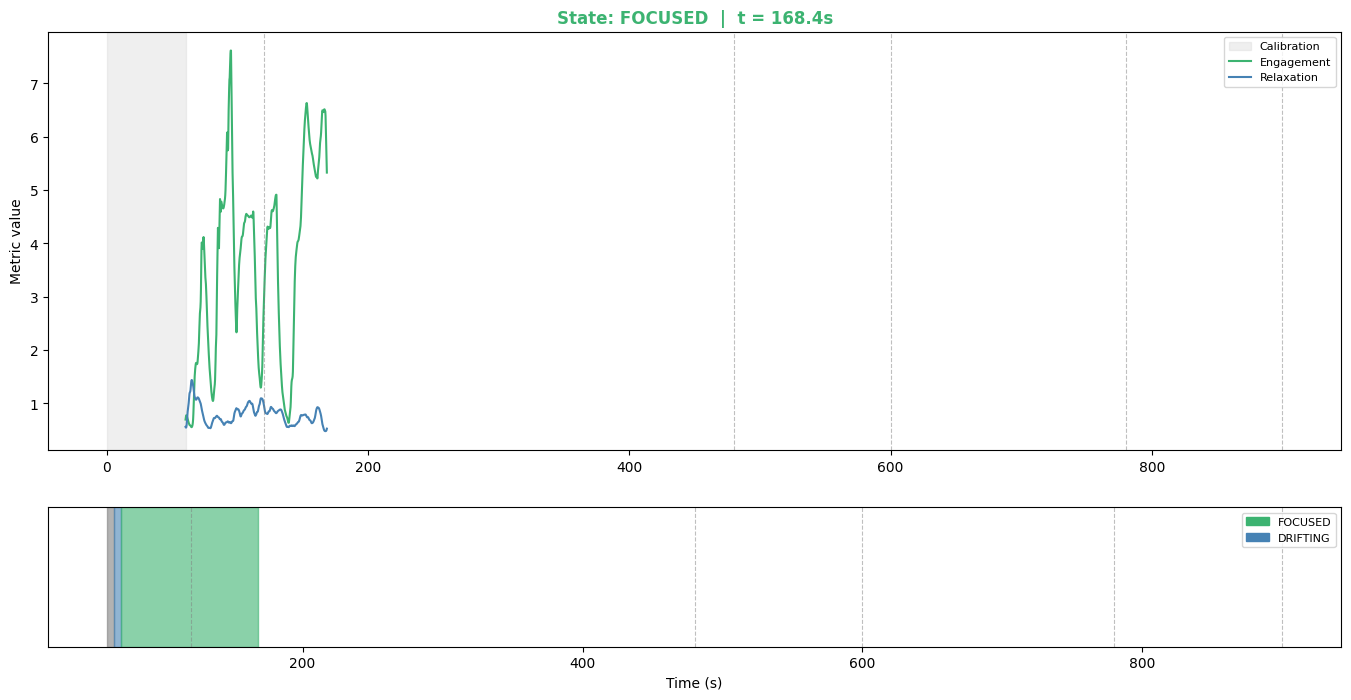

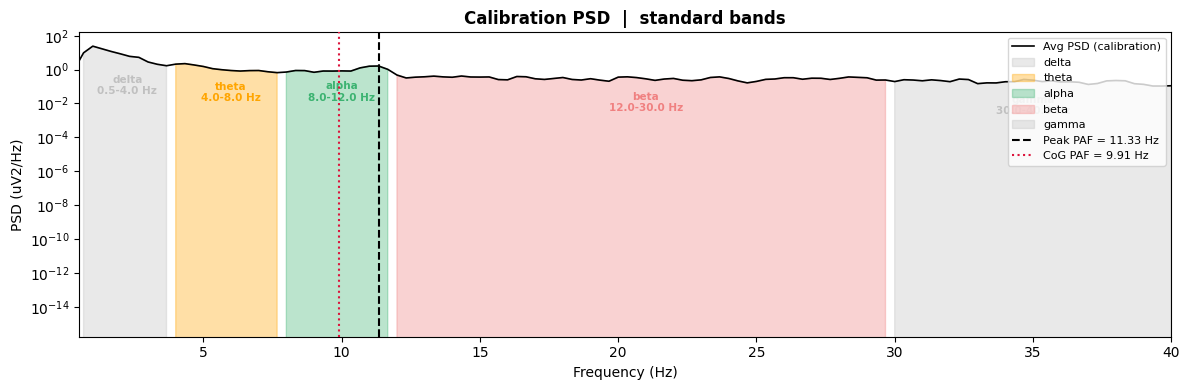

Calibration complete at t=60.2s
  theta_baseline = 4.67571
  IAF: using standard bands


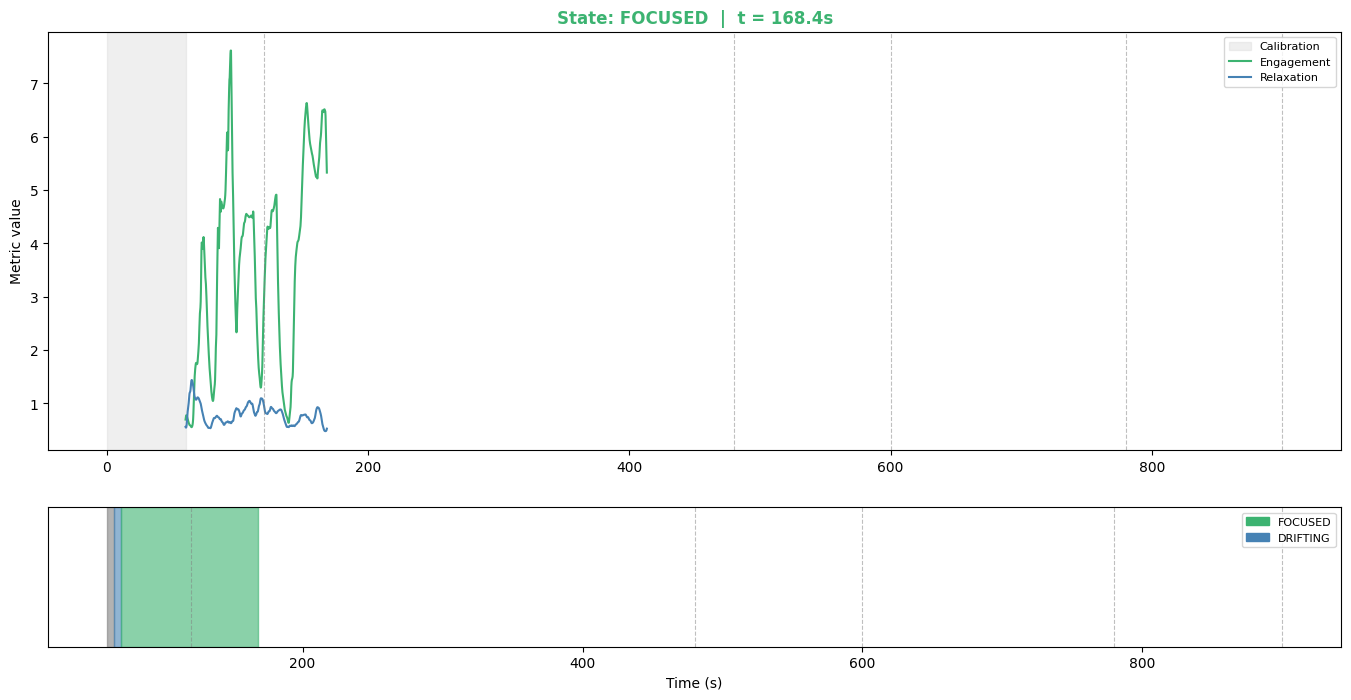

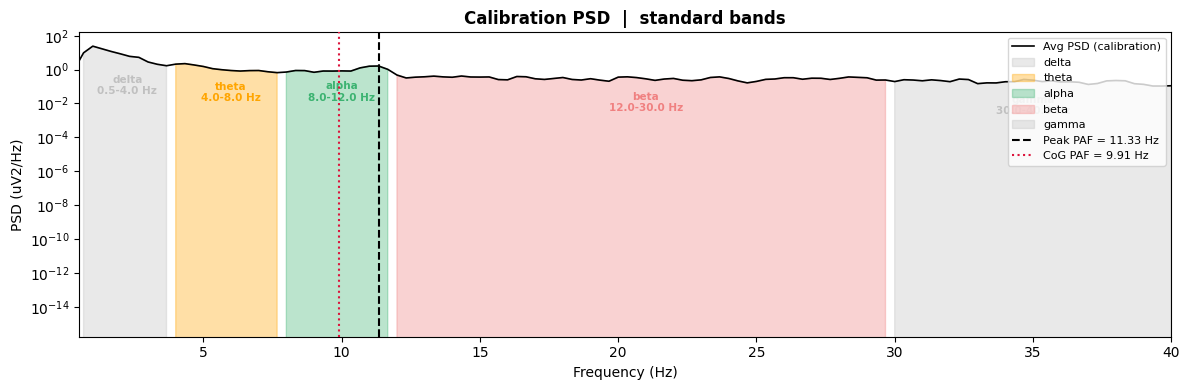

In [7]:
async def replay_csv(filepath: str, chunk_size: int, speed: float):
    df         = pd.read_csv(filepath)
    timestamps = df["timestamp"].values
    values     = df["ch1"].values
    t0         = timestamps[0]
    for i in range(0, len(df), chunk_size):
        end   = min(i + chunk_size, len(df))
        chunk = [{"timestamp": timestamps[j] - t0, "ch1": values[j]}
                 for j in range(i, end)]
        handle_live_data({"message": {"raw_eeg": chunk}})
        if end < len(df):
            await asyncio.sleep(max((timestamps[end] - timestamps[i]) / speed, 0))
    live_buffer.is_running = False


async def run_live():
    if not _SDK_AVAILABLE:
        raise ImportError(
            "idun_guardian_sdk is not installed. "
            "Run: pip install idun-guardian-sdk"
        )
    client = GuardianClient(api_token=MY_API_TOKEN, address=DEVICE_ADDRESS)
    client.subscribe_live_insights(raw_eeg=True, handler=handle_live_data)
    plot_task = asyncio.create_task(processing_loop())
    try:
        await client.start_recording(
            recording_timer=RECORDING_DURATION,
            led_sleep=False,
            calc_latency=False,
        )
    finally:
        live_buffer.is_running = False
        try:
            await plot_task
        except asyncio.CancelledError:
            pass


async def main():
    global _start_time, _hist_n, _dirty, _last_plot_time

    reset_state()
    reset_filter_state()
    live_buffer.timestamps.clear()
    live_buffer.ch1.clear()
    live_buffer.is_running = True
    _start_time     = None
    _hist_n         = 0
    _dirty          = False
    _last_plot_time = 0.0

    if MODE == "offline":
        plot_task = asyncio.create_task(processing_loop())
        try:
            await replay_csv(CSV_FILE, CHUNK_SIZE, PLAYBACK_SPEED)
        except asyncio.CancelledError:
            pass
        finally:
            live_buffer.is_running = False
            try:
                await plot_task
            except asyncio.CancelledError:
                pass
    elif MODE == "live":
        try:
            await run_live()
        except asyncio.CancelledError:
            pass
        finally:
            live_buffer.is_running = False
    else:
        raise ValueError(f"Unknown MODE={MODE!r}. Use 'offline' or 'live'.")

await main()